In [1]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from joblib import Parallel, delayed
import os

In [2]:
def gr_L_keni(T_l, A_l, tol=1e-16):
    N = T_l.shape[0]
    I = np.eye(N)

    A = np.block([
        [np.zeros((N, N)), I],
        [-T_l.conj().T, A_l]
    ])

    B = np.block([
        [I, np.zeros((N, N))],
        [np.zeros((N, N)), T_l]
    ])

    eigvals, eigvecs = eig(A, B)

    lambdas = []
    modes = []

    for i, lam in enumerate(eigvals):
        if np.abs(lam) < 1 - tol:   # 衰减模式
            x = eigvecs[:N, i]
            x /= np.linalg.norm(x)
            lambdas.append(lam)
            modes.append(x)

    X = np.column_stack(modes)
    Lambda = np.diag(lambdas)
    #print(Lambda.shape,X.shape)
    F = X @ Lambda @ np.linalg.inv(X)

    gL = np.linalg.inv(A_l - T_l @ F)

    check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    max_err = np.max(np.abs(check))
    if max_err > 1e-6:
        raise RuntimeError(
            f"Self-consistency violated: max |Δ| = {max_err:e}"
        )

    return gL

def gr_L(T_l, A_l, check_tol=1e-6):

    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  

    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
    check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    max_err = np.max(np.abs(check))
    if max_err > check_tol:
        mag = np.abs(eigvals)
        print("Sorted |eigvals|:", np.sort(mag))
        raise RuntimeError(
            fr"Self-consistency violated: max |Δ| = {max_err}"
        )

    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD_old(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, xshumu, E, eta=1e-6):

    d_device = H_q_list[0].shape[0]  
    d_lead = H_l.shape[0]            
    
    I_device = np.eye(d_device, dtype=complex)
    Z = np.zeros((d_device, d_device), dtype=complex)

    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    A_l = EI_lead - H_l
    gcl = gr_L_keni(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)


    A_r = EI_lead - H_r
    gcr = gr_L_keni(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    A_DD = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]

    for i in range(xshumu):
 
        H_q_i = H_q_list[i]

        if i == 0:
            A_DD[i][i] = EI_device - H_q_i - Sigma_L
        elif i == xshumu-1:
            A_DD[i][i] = EI_device - H_q_i - Sigma_R
        else:
            A_DD[i][i] = EI_device - H_q_i

        # 加上层间跃迁
        if i < xshumu-1:
            A_DD[i][i+1] = -T_21
        if i > 0:
            A_DD[i][i-1] = -T_21.conj().T

    A_DD = np.block(A_DD)

    G_DD_r = np.linalg.inv(A_DD)
    G_RL = G_DD_r[-d_device:, :d_device]
    return G_RL , Sigma_R, Sigma_L

def Gr_DD(H_DD, H_l, H_r, T_LD, T_l, T_RD, T_r, xshumu, E, eta=1e-6):
    d_device = H_DD[0][0].shape[0]  
    d_lead = H_l.shape[0]            
    
    I_device = np.eye(d_device, dtype=complex)
    Z = np.zeros((d_device, d_device), dtype=complex)

    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    A_l = EI_lead - H_l
    gcl = gr_L_keni(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_lead - H_r
    gcr = gr_L_keni(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    A_DD = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]

    for i in range(xshumu):
        H_q_i = H_DD[i][i]

        # 加上自能
        if i == 0:
            A_DD[i][i] = EI_device - H_q_i - Sigma_L
        elif i == xshumu-1:
            A_DD[i][i] = EI_device - H_q_i - Sigma_R
        else:
            A_DD[i][i] = EI_device - H_q_i

        # 加上层间跃迁 (非对角项，直接从 H_DD 中提取对应的块)
        if i < xshumu-1:
            A_DD[i][i+1] = -H_DD[i][i+1] 
        if i > 0:
            A_DD[i][i-1] = -H_DD[i][i-1]  

    A_DD_matrix = np.block(A_DD)

    G_DD_r = np.linalg.inv(A_DD_matrix)
    G_RL = G_DD_r[-d_device:, :d_device]
    return G_RL, Sigma_R, Sigma_L

def Gr_DD_2_old(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, xshumu, E, eta=1e-6):
    N = xshumu
    
    d_device = H_q_list[0].shape[0]  
    d_lead = H_l.shape[0]            
    
    I_device = np.eye(d_device, dtype=complex)
    

    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    A_l = EI_lead - H_l
    gcl = gr_L_keni(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_lead - H_r
    gcr = gr_L_keni(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    V = T_21
    V_dagger = V.conj().T
    
    # gL 数组存储从左向右扫描的局域有效格林函数
    gL = np.zeros((N, d_device, d_device), dtype=complex)
    
    # 1. 第 0 层 (最左侧)：包含本层哈密顿量和左电极自能
    gL[0] = np.linalg.inv(EI_device - H_q_list[0] - Sigma_L)
    
    # 2. 中间层：通过 Dyson 方程，把左侧所有层的物理效应折叠为本层的等效自能
    for n in range(1, N-1):
        Sigma_eff_L = V_dagger @ gL[n-1] @ V
        gL[n] = np.linalg.inv(EI_device - H_q_list[n] - Sigma_eff_L)
        
    # 3. 第 N-1 层 (最右侧)：包含左侧传播来的等效自能，以及真实的右电极自能
    Sigma_eff_L_last = V_dagger @ gL[N-2] @ V
    gL[N-1] = np.linalg.inv(EI_device - H_q_list[N-1] - Sigma_eff_L_last - Sigma_R)
    
    # 4. 回溯提取透射矩阵 G_RL (即 G_{N-1, 0}，波函数从左侧 0 传播到右侧 N-1)
    G_RL = gL[N-1].copy()
    for n in range(N-2, -1, -1):
        G_RL = G_RL @ V_dagger @ gL[n]

    # 直接返回这三个计算电导的必需品，G_RL 的维度是 160x160
    return G_RL, Sigma_R, Sigma_L

def Gr_DD_2(H_DD, H_l, H_r, T_LD, T_l, T_RD, T_r, xshumu, E, eta=1e-6):
    """
    修改后的递归格林函数计算 (RGF方法)
    :param H_DD: 传入 H_center[1]，即包含所有在位能和层间跃迁的二维列表
    """
    N = xshumu
    
    # 直接从 H_DD 获取 device 维度
    d_device = H_DD[0][0].shape[0]  
    d_lead = H_l.shape[0]            
    
    I_device = np.eye(d_device, dtype=complex)
    
    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    A_l = EI_lead - H_l
    gcl = gr_L_keni(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_lead - H_r
    gcr = gr_L_keni(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    # gL 数组存储从左向右扫描的局域有效格林函数
    gL = np.zeros((N, d_device, d_device), dtype=complex)
    
    # 1. 第 0 层 (最左侧)：包含本层哈密顿量和左电极自能
    gL[0] = np.linalg.inv(EI_device - H_DD[0][0] - Sigma_L)
    
    # 2. 中间层：通过 Dyson 方程，把左侧所有层的物理效应折叠为本层的等效自能
    for n in range(1, N-1):
        # 动态提取两层之间的跃迁矩阵 (支持 SSH 和无序)
        V = H_DD[n-1][n]          # 从 n-1 跃迁到 n
        V_dagger = H_DD[n][n-1]   # 从 n 跃迁回 n-1
        
        Sigma_eff_L = V_dagger @ gL[n-1] @ V
        gL[n] = np.linalg.inv(EI_device - H_DD[n][n] - Sigma_eff_L)
        
    # 3. 第 N-1 层 (最右侧)：包含左侧传播来的等效自能，以及真实的右电极自能
    V_last = H_DD[N-2][N-1]
    V_dagger_last = H_DD[N-1][N-2]
    Sigma_eff_L_last = V_dagger_last @ gL[N-2] @ V_last
    gL[N-1] = np.linalg.inv(EI_device - H_DD[N-1][N-1] - Sigma_eff_L_last - Sigma_R)
    
    # 4. 回溯提取透射矩阵 G_RL (即 G_{N-1, 0}，波函数从左侧 0 传播到右侧 N-1)
    G_RL = gL[N-1].copy()
    for n in range(N-2, -1, -1):
        # 回溯时使用的跃迁矩阵是从 n+1 回到 n (对应原代码的 V_dagger)
        V_dagger_back = H_DD[n+1][n]  
        G_RL = G_RL @ V_dagger_back @ gL[n]

    return G_RL, Sigma_R, Sigma_L


In [7]:
#参数
def H_onstie(u):
    return u * np.array([[1]], dtype=complex)

def H_hop(t):
    return t*np.array([[1]], dtype=complex)

def generate_sequence(n, A, B):
    if n == 0:
        seq = [B]
        return seq, len(seq), 0, 1  # 返回: 序列, 总数, A的数量, B的数量
    elif n == 1:
        seq = [A]
        return seq, len(seq), 1, 0
        
    c_prev2 = [B] 
    c_prev1 = [A]  
    
    # 同步维护 A 和 B 的数量计数
    # count_A_prev1 代表 c_prev1 中 A 的数量，以此类推
    count_A_prev2, count_B_prev2 = 0, 1
    count_A_prev1, count_B_prev1 = 1, 0
    
    for _ in range(2, n + 1):
        current_seq = c_prev1 + c_prev2
        
        # 数量同样按照斐波那契递推规律进行累加
        current_A = count_A_prev1 + count_A_prev2
        current_B = count_B_prev1 + count_B_prev2
        
        # 滚动更新状态
        c_prev2 = c_prev1
        c_prev1 = current_seq
        
        count_A_prev2, count_B_prev2 = count_A_prev1, count_B_prev1
        count_A_prev1, count_B_prev1 = current_A, current_B
        
    return current_seq, len(current_seq), current_A, current_B

def H_old(H_q_list, T_21_list, xshumu):
    d_device = H_q_list[0].shape[0]            
    Z = np.zeros((d_device, d_device), dtype=complex)
    H_DD = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]
    
    for i in range(xshumu):
        H_DD[i][i] = H_q_list[i]  
        
        if i < xshumu - 1:
            H_DD[i][i+1] = T_21_list[i]
            
        if i > 0:
            H_DD[i][i-1] = T_21_list[i-1].conj().T 
    
    H_DD_1=np.block(H_DD)
    return H_DD_1,H_DD

def H(H_q_list, T_21_list, xshumu, cengshu, T_cengjian,random_potentials):
    d_device = H_q_list[0].shape[0]            
    Z = np.zeros((d_device, d_device), dtype=complex)
    I_device = np.eye(d_device, dtype=complex)
    
    # 根据层数计算总节点数
    total_sites = xshumu * cengshu
    H_DD = [[Z.copy() for _ in range(total_sites)] for _ in range(total_sites)]
    
    # ================= 1. 构建第一层 (前上角) =================
    for i in range(xshumu):
        H_DD[i][i] = H_q_list[i]  
        
        if i < xshumu - 1:
            H_DD[i][i+1] = T_21_list[i]
            
        if i > 0:
            H_DD[i][i-1] = T_21_list[i-1].conj().T 
            
    # ================= 2. 构建第二层 (后下角) 和 层间耦合 =================
    if cengshu == 2:
        for i in range(xshumu):
            # i_new 是第二层在大矩阵中的绝对索引 (xshumu 到 2*xshumu-1)
            i_new = xshumu + i
            # i_old 是对应第一层中被翻转过来的对称索引 (从 xshumu-1 倒着数)
            i_old = xshumu - 1 - i 
            
            # (1) 在位能翻转 (后下角的左上角对应前上角的右下角)
            H_DD[i_new][i_new] = H_q_list[i_old]
            
            # (2) 跳跃矩阵翻转
            if i < xshumu - 1:
                # 按照你的要求，后下角的第一个跳跃 [0][1] 对应前上角的 [xshumu-2][xshumu-1].conj().T
                # i_old - 1 正好对应前上角的相应跃迁的索引
                T_forward = T_21_list[i_old - 1].conj().T
                
                H_DD[i_new][i_new+1] = T_forward
                H_DD[i_new+1][i_new] = T_forward.conj().T
        
        # (3) 添加层间耦合 T_cengjian
        # 层间耦合连接着第一层的最后一个格点和第二层的第一个格点 (形成 U 型连接)
        
        H_DD[xshumu-1][xshumu] = T_cengjian
        H_DD[xshumu][xshumu-1] = T_cengjian.conj().T

    # ================= 3. 附加无序势 (全新循环) =================
    if random_potentials is not None:
        for i in range(total_sites):
            # 将无序势乘以单位矩阵后直接累加到现有的对角项上
            H_DD[i][i] = H_DD[i][i] + random_potentials[i] * I_device

    # 将分块列表转化为一个大型 numpy 矩阵
    H_DD_1 = np.block(H_DD)
    
    return H_DD_1, H_DD

#一般
mu_q=0
mu_r=0
mu_l=0
t=-1

#准周期
n=8
A=0
B=0
zhun_list, xshumu, lenA, lenB = generate_sequence(n, A, B)
#A=A/lenA*lenB
#B=B/lenB*lenA
#zhun_list, xshumu, lenA, lenB = generate_sequence(n, A, B)
print(xshumu, lenA, lenB )
#print(zhun_list)

#中间的层数翻倍与层间的T
cengshu=1
cengjian=t*1
T_cengjian=H_hop(cengjian)

#无序
W_disorder = 3
random_potentials = np.random.uniform(-W_disorder/2, W_disorder/2, xshumu*cengshu)

#SSH
t_a=t*1
t_b=t*1

#xshumu=xshumu-2
#中间
T_21 = H_hop(t)
H_q=H_onstie(mu_q)

T_21_a=H_hop(t_a)
T_21_b= H_hop(t_b)

H_q_list = []
for i in range(xshumu):      
    total_mu = mu_q + zhun_list[i] 
    H_q_random = H_onstie(total_mu)
    H_q_list.append(H_q_random)

T_21_list=[]
for i in range(xshumu-1):
    if i%2==0:
        T_21_list.append(T_21_a)
    else:
        T_21_list.append(T_21_b)


#输出左边矩阵
H_l = H_onstie(mu_l)
T_l = H_hop(t).conj().T

#输出右边矩阵
H_r = H_onstie(mu_r)
T_r = H_hop(t)

#输出耦合矩阵
T_LD = H_hop(t)
T_RD = H_hop(t).conj().T

#输出中间区域矩阵
H_center = H(H_q_list, T_21_list, xshumu, cengshu, T_cengjian,random_potentials)


34 21 13


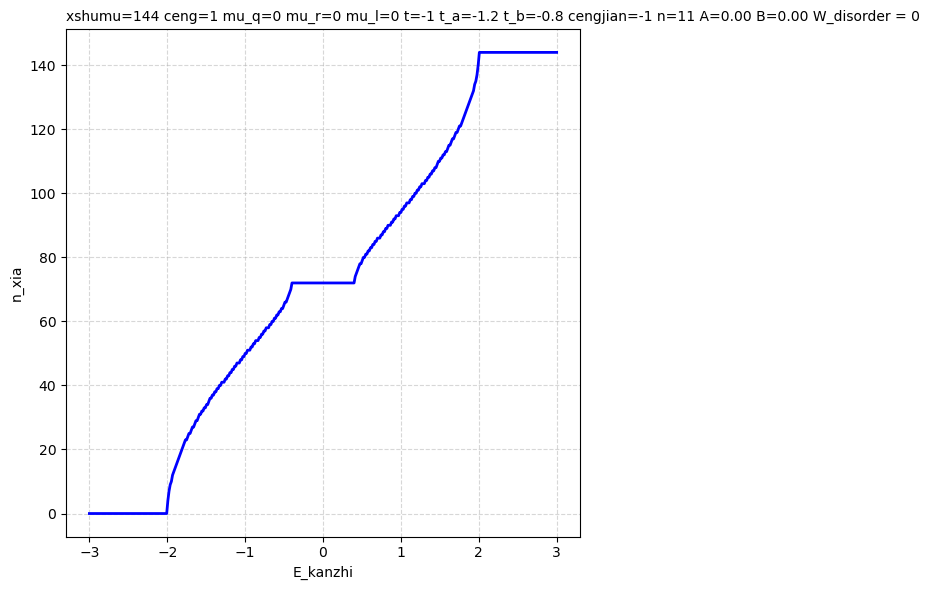

In [23]:
#中间能量分布
# 1. 计算哈密顿量矩阵
H_matrix = H_center[0]

# 2. 对角化求解本征值和本征态
# np.linalg.eigh 专用于厄米矩阵，算出来的本征值 eigenvalues 已经是从小到大排好序的
eigenvalues, eigenvectors = np.linalg.eigh(H_matrix)

# 图的标准标题定义
fig_title = rf"xshumu={xshumu} ceng={cengshu} mu_q={mu_q} mu_r={mu_r} mu_l={mu_l} t={t} t_a={t_a} t_b={t_b} cengjian={cengjian} n={n} A={A:.2f} B={B:.2f} W_disorder = {W_disorder}"

# 3. 绘制 E_kanzhi vs 计数图
E_min = np.min(eigenvalues)
E_max = np.max(eigenvalues)

# 在 [E_min - 1, E_max + 1] 范围内取 300 个点
E_kanzhi_axis = np.linspace(E_min - 1, E_max + 1, 400)
counts = []

for e_k in E_kanzhi_axis:
    # 统计小于 E_kanzhi 的本征值数目
    count = np.sum(eigenvalues < e_k)
    counts.append(count)

plt.figure(figsize=(6, 6))
plt.plot(E_kanzhi_axis, counts, 'b-', linewidth=2)
plt.xlabel("E_kanzhi")
plt.ylabel("n_xia")
#plt.ylim(-3,3)
#plt.xlim(-1,1)
plt.title(fig_title, fontsize=10, loc='left')
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()



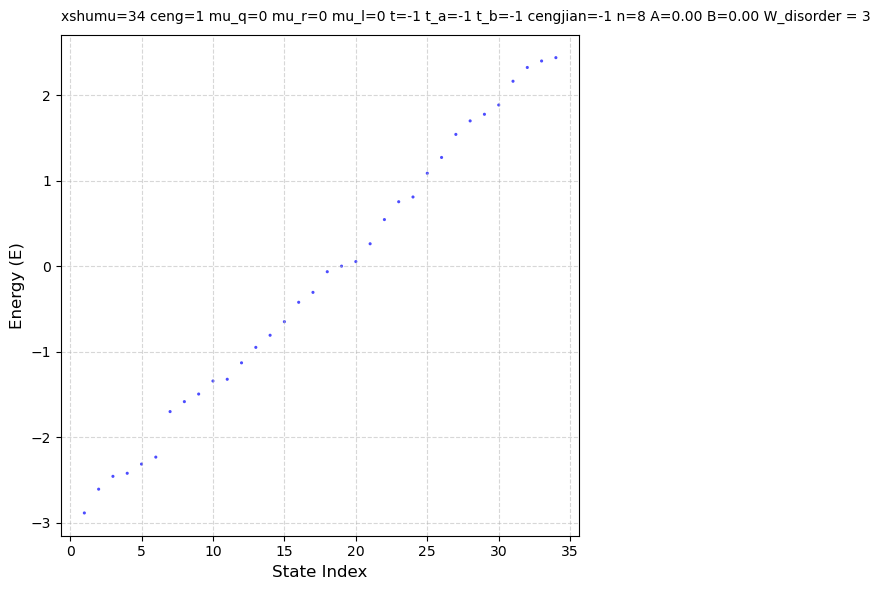

In [8]:
# 1. 计算哈密顿量矩阵
H_matrix = H_center[0]

# 2. 对角化求解本征值和本征态
eigenvalues, eigenvectors = np.linalg.eigh(H_matrix)

# 图的标准标题定义
fig_title = rf"xshumu={xshumu} ceng={cengshu} mu_q={mu_q} mu_r={mu_r} mu_l={mu_l} t={t} t_a={t_a} t_b={t_b} cengjian={cengjian} n={n} A={A:.2f} B={B:.2f} W_disorder = {W_disorder}"

# ================= 修改后的 1维 E图 绘制代码 =================

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6, 6))

# 画法 1：Energy vs State Index (最常用，看能带/能隙最清晰)
# 横坐标是 0 到 N-1 的索引，纵坐标是能量值
state_indices = np.arange(1,len(eigenvalues)+1)
plt.scatter(state_indices, eigenvalues, c='b', s=5, alpha=0.7, edgecolors='none')

# --- 如果你想看“所有点挤在一条线上”的纯1D分布，可以注释掉上面两行，使用下面这行 ---
# plt.scatter(np.zeros_like(eigenvalues), eigenvalues, c='b', s=5, alpha=0.3, edgecolors='none')
# plt.xlim(-1, 1) # 把横坐标限制住，让点集中在中间

plt.xlabel("State Index", fontsize=12)
plt.ylabel("Energy (E)", fontsize=12)

# 根据需要放开能量区间限制，方便看零能附近的态 (比如拓扑边缘态)
# plt.ylim(-3, 3) 

plt.title(fig_title, fontsize=10, loc='left', pad=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [9]:
#画波函数的
# 4. 绘制并保存每个本征态的概率分布图
# 创建保存的目标文件夹
save_dir = rf"D:\结果\2026.7.3\{fig_title}"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"已成功创建文件夹: {save_dir}")

print("正在绘制并保存各个本征态的概率分布图，请稍候...")
# 遍历每一个本征值及其对应的本征态
for idx in range(len(eigenvalues)):
    E_val = eigenvalues[idx]
    # 获取对应的本征波函数波矢
    psi = eigenvectors[:, idx]
    # 计算每个格点上的概率分布：波函数的模平方
    prob_dist = np.abs(psi) ** 2
    
    # 绘图
    plt.figure(figsize=(8, 4))
    plt.bar(range(1, xshumu*cengshu + 1), prob_dist, color='crimson', alpha=0.7, edgecolor='k')
    
    plt.xlabel("Site Index")
    plt.ylabel("Probability Distribution")
    plt.title(f"{fig_title}\nState No: {idx+1} | E = {E_val:.4f}", fontsize=9, loc='left')
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    
    # 文件命名格式保持不变: [数量序号]_E_[本征值].png
    file_name = f"{idx+1:03d}_E_{E_val:.4f}.png"
    file_path = os.path.join(save_dir, file_name)
    
    plt.savefig(file_path, dpi=150)
    plt.close() # 关闭当前画布，释放内存

print(f"所有本征态图已全部成功保存至: {save_dir}")

已成功创建文件夹: D:\结果\2026.7.3\xshumu=34 ceng=1 mu_q=0 mu_r=0 mu_l=0 t=-1 t_a=-1 t_b=-1 cengjian=-1 n=8 A=0.00 B=0.00 W_disorder = 3
正在绘制并保存各个本征态的概率分布图，请稍候...
所有本征态图已全部成功保存至: D:\结果\2026.7.3\xshumu=34 ceng=1 mu_q=0 mu_r=0 mu_l=0 t=-1 t_a=-1 t_b=-1 cengjian=-1 n=8 A=0.00 B=0.00 W_disorder = 3


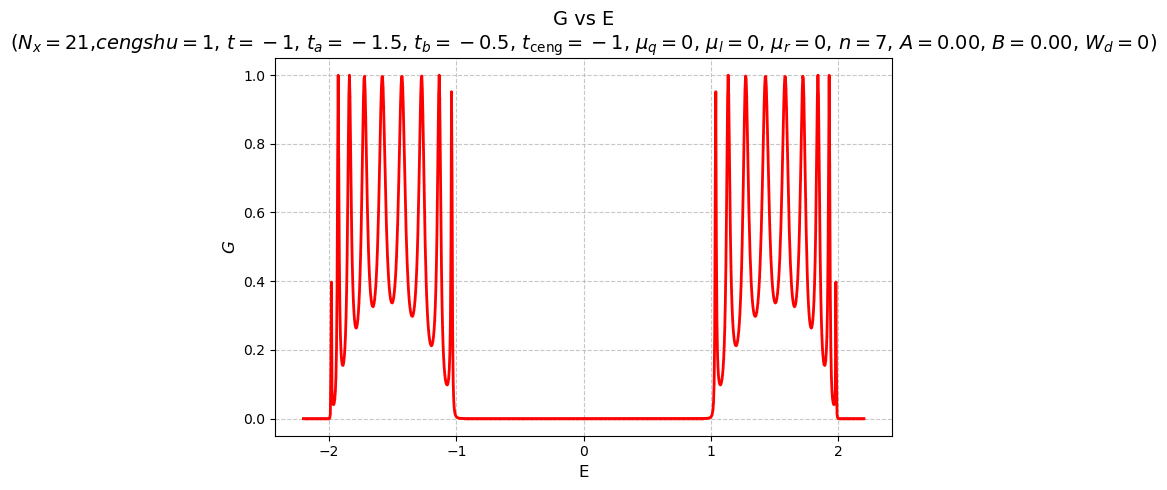

In [53]:
#电导
E_set=np.linspace(-2.2, 2.2, 1000)
G_set=[]
for E in E_set:
    G_RL, Sigma_R, Sigma_L = Gr_DD_2(H_center[1], H_l, H_r, T_LD, T_l, T_RD, T_r, xshumu*cengshu, E)

    zhankuanL = 1j * (Sigma_L - Sigma_L.conj().T)
    zhankuanR = 1j * (Sigma_R - Sigma_R.conj().T)
        
    G_complex = np.trace(zhankuanR @ G_RL @ zhankuanL @ G_RL.conj().T)
    G_set.append(G_complex)
    
plt.figure(figsize=(7, 5))
plt.plot(E_set, np.real(G_set), marker='o', markersize=0.1, color='r', linewidth=2, linestyle='-')
plt.title(
    f"G vs E\n"
    rf"($N_x={xshumu}$,$cengshu={cengshu}$, $t={t}$, $t_a={t_a}$, $t_b={t_b}$, $t_{{\mathrm{{ceng}}}}={cengjian}$, $\mu_q={mu_q}$, $\mu_l={mu_l}$, $\mu_r={mu_r}$, $n={n}$, $A={A:.2f}$, $B={B:.2f}$, $W_d={W_disorder}$)", 
    fontsize=14
)
plt.xlabel(r'E', fontsize=12)
plt.ylabel(r'$G$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [24]:
#电导 单个看看
E=0.1
G_RL, Sigma_R, Sigma_L = Gr_DD_2(H_center[1], H_l, H_r, T_LD, T_l, T_RD, T_r, xshumu*cengshu, E)
zhankuanL = 1j * (Sigma_L - Sigma_L.conj().T)
zhankuanR = 1j * (Sigma_R - Sigma_R.conj().T)       
G_complex = np.trace(zhankuanR @ G_RL @ zhankuanL @ G_RL.conj().T)
print(G_complex.real)

2.301803273029098e-09


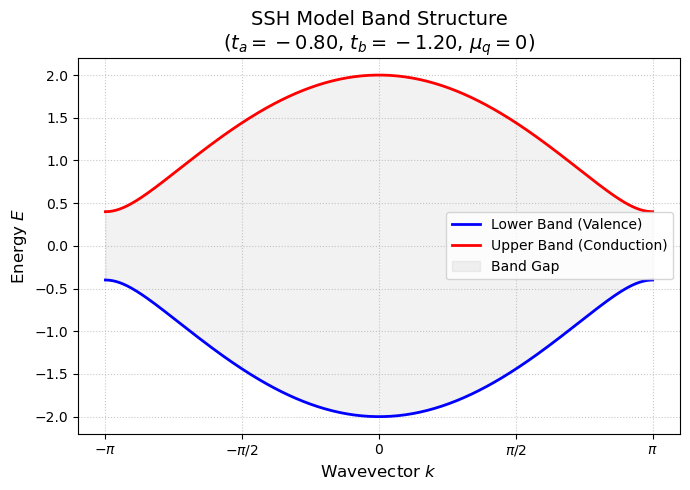

In [26]:
#SSH模型能带
# 取布里渊区 k 从 -pi 到 pi
k_vals = np.linspace(-np.pi, np.pi, 300)

# 用于存储两条能带的本征值
E_bands = np.zeros((len(k_vals), 2))

for i, k in enumerate(k_vals):
    # 构造 2x2 的 H(k) 矩阵
    # 胞内跃迁 t_a, 胞间跃迁 t_b
    off_diag = t_a + t_b * np.exp(-1j * k)
    
    H_k = np.array([
        [mu_q, off_diag],
        [np.conj(off_diag), mu_q]
    ])
    
    # 求解厄米矩阵的本征值，eigvalsh 保证返回实数且从小到大排序
    evals = np.linalg.eigvalsh(H_k)
    E_bands[i, :] = evals

# 开始画图
plt.figure(figsize=(7, 5))

# 画出两条能带
plt.plot(k_vals, E_bands[:, 0], color='blue', linewidth=2, label='Lower Band (Valence)')
plt.plot(k_vals, E_bands[:, 1], color='red', linewidth=2, label='Upper Band (Conduction)')

# 如果有带隙，用灰色填充显示带隙位置（可选，为了好看）
plt.fill_between(k_vals, E_bands[:, 0], E_bands[:, 1], color='gray', alpha=0.1, label='Band Gap')

plt.title(f'SSH Model Band Structure\n' + 
          rf'($t_a={t_a:.2f}$, $t_b={t_b:.2f}$, $\mu_q={mu_q}$)', fontsize=14)
plt.xlabel(r'Wavevector $k$', fontsize=12)
plt.ylabel('Energy $E$', fontsize=12)

# 设置 x 轴刻度为 -π 到 π
plt.xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi],
           [r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])

plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

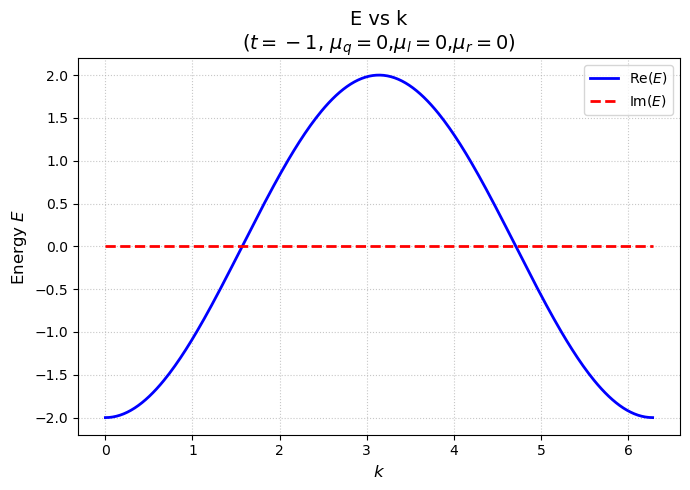

In [ ]:
#一般的能带 来看能量范围 
k_vals = np.linspace(0, 2 * np.pi, 300)
E_k_matrix = H_q + T_21 * np.exp(1j * k_vals) + T_21.conj().T * np.exp(-1j * k_vals)
E_k = np.squeeze(E_k_matrix)

plt.figure(figsize=(7, 5))
plt.plot(k_vals, np.real(E_k), color='blue', linewidth=2, label=r'$\operatorname{Re}(E)$')
plt.plot(k_vals, np.imag(E_k), color='red', linewidth=2, linestyle='--', label=r'$\operatorname{Im}(E)$')
plt.title(f'E vs k\n' + 
          rf'($t={t}$, $\mu_q={mu_q}$,$\mu_l={mu_l}$,$\mu_r={mu_r}$)', fontsize=14)
plt.xlabel(r'$k$', fontsize=12)
plt.ylabel('Energy $E$', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

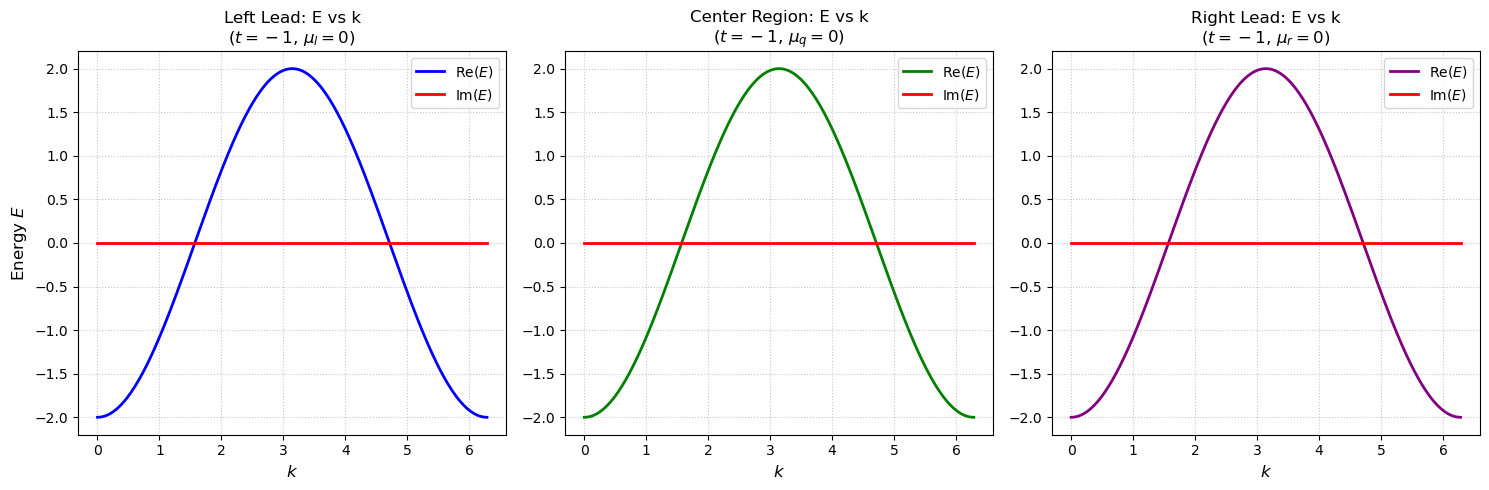

In [ ]:
#能量范围 
# 统一的 k 值范围
k_vals = np.linspace(0, 2 * np.pi, 300)

# 1. 计算中间区域的能带
E_k_matrix_q = H_q + T_21 * np.exp(1j * k_vals) + T_21.conj().T * np.exp(-1j * k_vals)
E_k_q = np.squeeze(E_k_matrix_q)

# 2. 计算左边导线的能带
E_k_matrix_l = H_l + T_l * np.exp(1j * k_vals) + T_l.conj().T * np.exp(-1j * k_vals)
E_k_l = np.squeeze(E_k_matrix_l)

# 3. 计算右边导线的能带
E_k_matrix_r = H_r + T_r * np.exp(1j * k_vals) + T_r.conj().T * np.exp(-1j * k_vals)
E_k_r = np.squeeze(E_k_matrix_r)

# ==========================================
# 开始绘制 1x3 的子图
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- 子图 1：左边导线 (Left Lead) ---
axes[0].plot(k_vals, np.real(E_k_l), color='blue', linewidth=2, label=r'$\operatorname{Re}(E)$')
axes[0].plot(k_vals, np.imag(E_k_l), color='red', linewidth=2, label=r'$\operatorname{Im}(E)$')
axes[0].set_title(
    f"Left Lead: E vs k\n"
    rf"($t={t}$, $\mu_l={mu_l}$)", 
    fontsize=12
)
axes[0].set_xlabel(r'$k$', fontsize=12)
axes[0].set_ylabel('Energy $E$', fontsize=12)
axes[0].grid(True, linestyle=':', alpha=0.7)
axes[0].legend()

# --- 子图 2：中间区域 (Center Region) ---
axes[1].plot(k_vals, np.real(E_k_q), color='green', linewidth=2, label=r'$\operatorname{Re}(E)$')
axes[1].plot(k_vals, np.imag(E_k_q), color='red', linewidth=2, label=r'$\operatorname{Im}(E)$')
axes[1].set_title(
    f"Center Region: E vs k\n"
    rf"($t={t}$, $\mu_q={mu_q}$)", 
    fontsize=12
)
axes[1].set_xlabel(r'$k$', fontsize=12)
# 省略 Y 轴标签使画面更清爽，因为三个图共用能量概念
axes[1].grid(True, linestyle=':', alpha=0.7)
axes[1].legend()

# --- 子图 3：右边导线 (Right Lead) ---
axes[2].plot(k_vals, np.real(E_k_r), color='purple', linewidth=2, label=r'$\operatorname{Re}(E)$')
axes[2].plot(k_vals, np.imag(E_k_l), color='red', linewidth=2, label=r'$\operatorname{Im}(E)$')
axes[2].set_title(
    f"Right Lead: E vs k\n"
    rf"($t={t}$, $\mu_r={mu_r}$)", 
    fontsize=12
)
axes[2].set_xlabel(r'$k$', fontsize=12)
axes[2].grid(True, linestyle=':', alpha=0.7)
axes[2].legend()

# 自动调整子图间距，防止标题或标签重叠
plt.tight_layout()
plt.show()